### Autoencoders (AE), Variational Autoencoders (VAE), and Latent Space Interpolation using PyTorch and the MNIST dataset.

This setup builds a 2D latent space so participants can visualize how image compression, continuous distributions, and latent space traversal work in generative models (like Latent Diffusion Models).


### Cell 1: Install & Import Libraries
Installs torchvision and imports tools for building models and visual plots.



In [ ]:
# Cell 1: Environment Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on device: {device}")

Running on device: cuda


### Cell 2: Load MNIST Dataset
Loads the standard 28x28 grayscale digits.

In [ ]:
# Cell 2: Data Loader
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Loaded {len(train_dataset)} training images.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 513kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]

Loaded 60000 training images.


### Cell 3: Define a Variational Autoencoder (VAE)Implements the encoder, the reparameterization trick ($\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$), decoder, and KL Divergence loss.

In [ ]:
# Cell 3: VAE Architecture with a 2D Latent Space
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        # Encoder: 784 (28x28) -> 400 -> Latent mu, logvar
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder: Latent -> 400 -> 784
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Reparameterization Trick: z = mu + std * eps
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        x_flat = x.view(-1, 784)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

# Loss Function: Reconstruction (BCE) + Regularization (KL Divergence)
def vae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # Closed-form KL Divergence for Gaussian prior N(0, I)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

vae = VAE(latent_dim=2).to(device)
print("VAE model initialized.")

VAE model initialized.


### Cell 4: Train the VAE
Trains the VAE for 10 fast epochs (~30 seconds on GPU).

In [ ]:
# Cell 4: Train VAE
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

vae.train()
for epoch in range(1, 11):
    train_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = vae(x)
        loss = vae_loss_function(recon_batch, x, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f"Epoch [{epoch}/10] - Avg Loss: {train_loss / len(train_loader.dataset):.2f}")

Epoch [1/10] - Avg Loss: 189.00
Epoch [2/10] - Avg Loss: 166.99
Epoch [3/10] - Avg Loss: 163.83
Epoch [4/10] - Avg Loss: 161.75
Epoch [5/10] - Avg Loss: 160.11
Epoch [6/10] - Avg Loss: 159.03
Epoch [7/10] - Avg Loss: 158.02
Epoch [8/10] - Avg Loss: 157.21
Epoch [9/10] - Avg Loss: 156.49
Epoch [10/10] - Avg Loss: 155.86


### Cell 5: Plot 2D Latent Space Clusters
Encodes test dataset images and visualizes how different visual concepts (digit classes) organize naturally in 2D space.

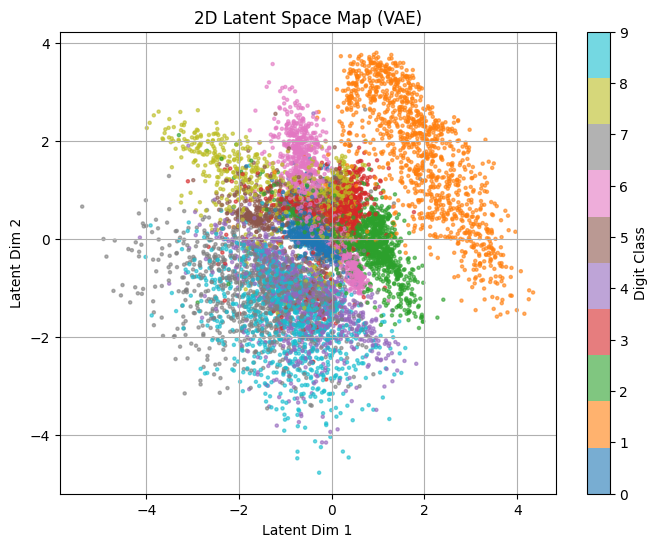

In [ ]:
# Cell 5: Latent Space Scatter Plot
vae.eval()
latents, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = vae.encode(x.view(-1, 784))
        latents.append(mu.cpu())
        labels.append(y)

latents = torch.cat(latents, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter, label='Digit Class')
plt.title("2D Latent Space Map (VAE)")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.grid(True)
plt.show()

### Cell 6: Latent Space Interpolation (Generative Walk)
- Performs linear interpolation between two distinct points in the continuous latent space ($z_{\text{start}}$ to $z_{\text{end}}$) to show smooth image morphing.

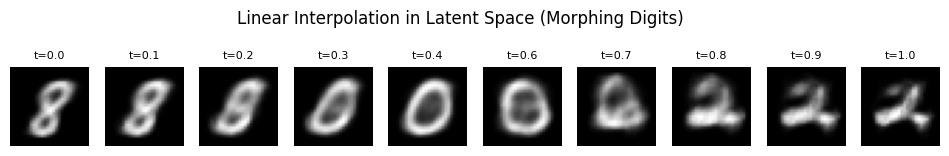

In [ ]:
# Cell 6: Latent Space Linear Interpolation
vae.eval()

# Pick two random points in 2D latent space
z_start = torch.tensor([[-2.0, 1.5]], device=device)
z_end = torch.tensor([[2.0, -1.5]], device=device)

# Interpolate 10 steps linearly between z_start and z_end
steps = 10
alpha = torch.linspace(0, 1, steps, device=device).unsqueeze(1)
z_interp = (1 - alpha) * z_start + alpha * z_end

with torch.no_grad():
    generated_images = vae.decode(z_interp).view(-1, 28, 28).cpu()

# Plot interpolation sequence
fig, axes = plt.subplots(1, steps, figsize=(12, 2))
for i in range(steps):
    axes[i].imshow(generated_images[i], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"t={i/(steps-1):.1f}", fontsize=8)

plt.suptitle("Linear Interpolation in Latent Space (Morphing Digits)")
plt.show()

Dimensionality Reduction: An input image ($28 \times 28 = 784$ dimensions) is compressed down to a $2$-dimensional vector $\mathbf{z}$.

Autoencoders vs. VAEs:

- Vanilla Autoencoders map inputs to discrete points, creating discrete clusters separated by empty regions (gaps produce random noise when sampled).

- VAEs use KL divergence to enforce a continuous, dense Gaussian distribution $\mathcal{N}(0, \mathbf{I})$ over the latent space.


Role in Modern Generative Models: Models like Stable Diffusion 1.5 and FLUX run noise reduction inside an $8 \times$ downsampled VAE latent space ($64 \times 64 \times 4$ tensor) instead of pixel space ($512 \times 512 \times 3$), drastically cutting memory requirements and compute complexity.